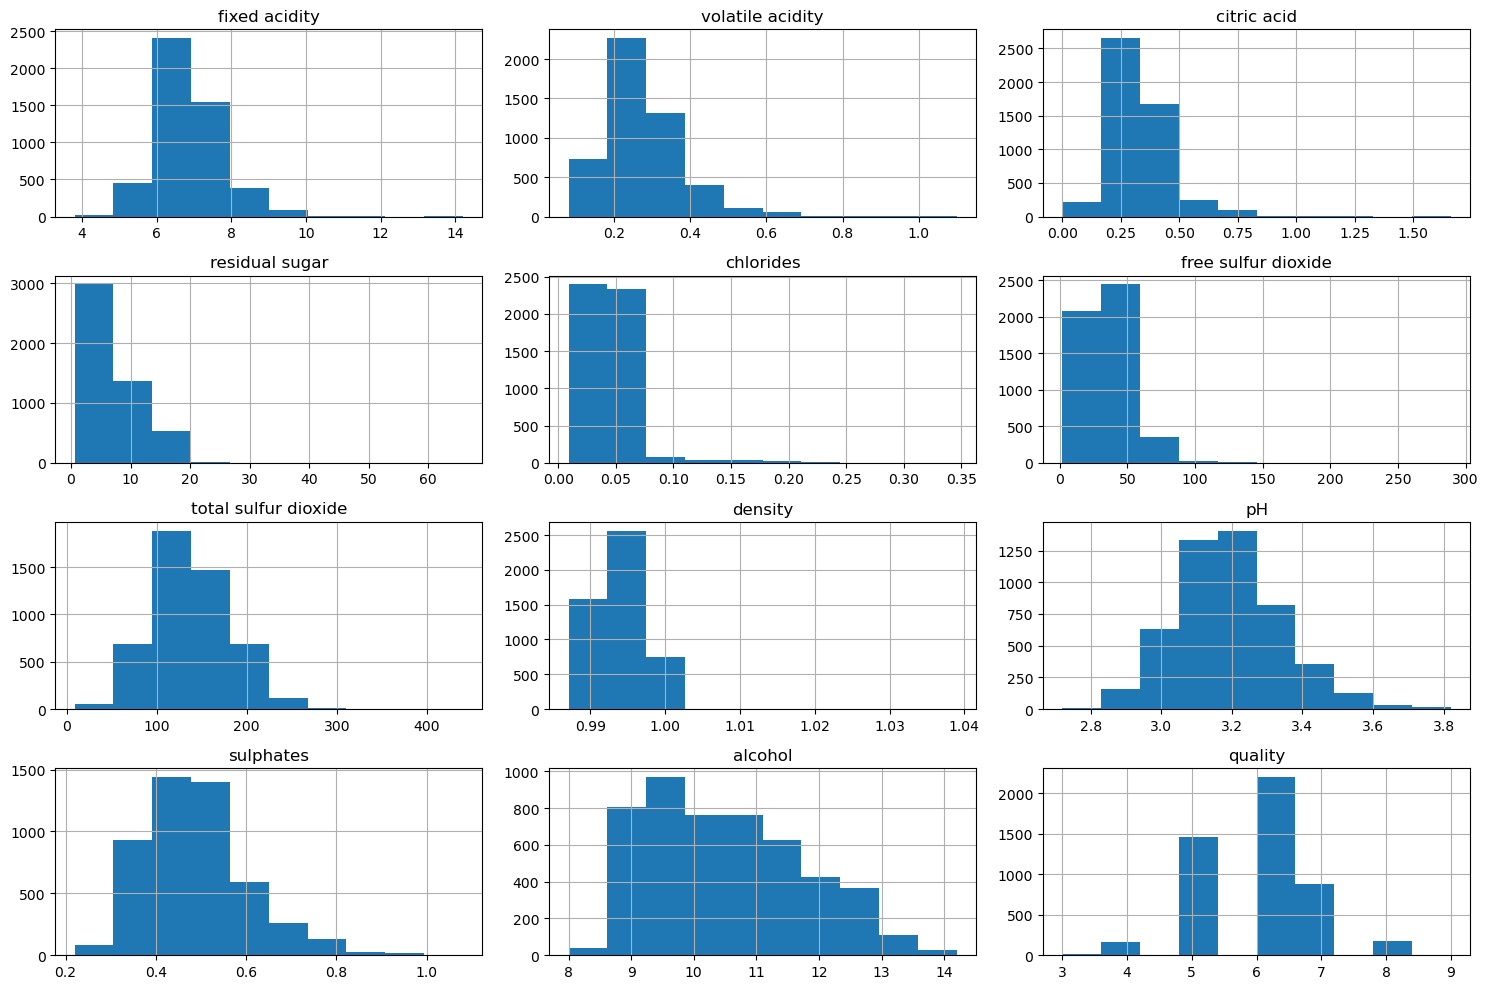

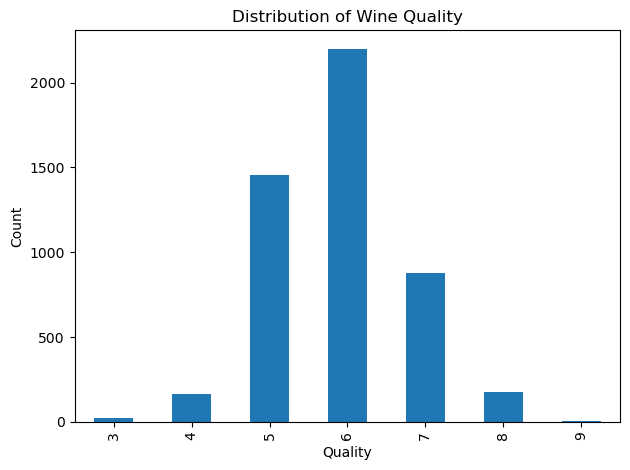

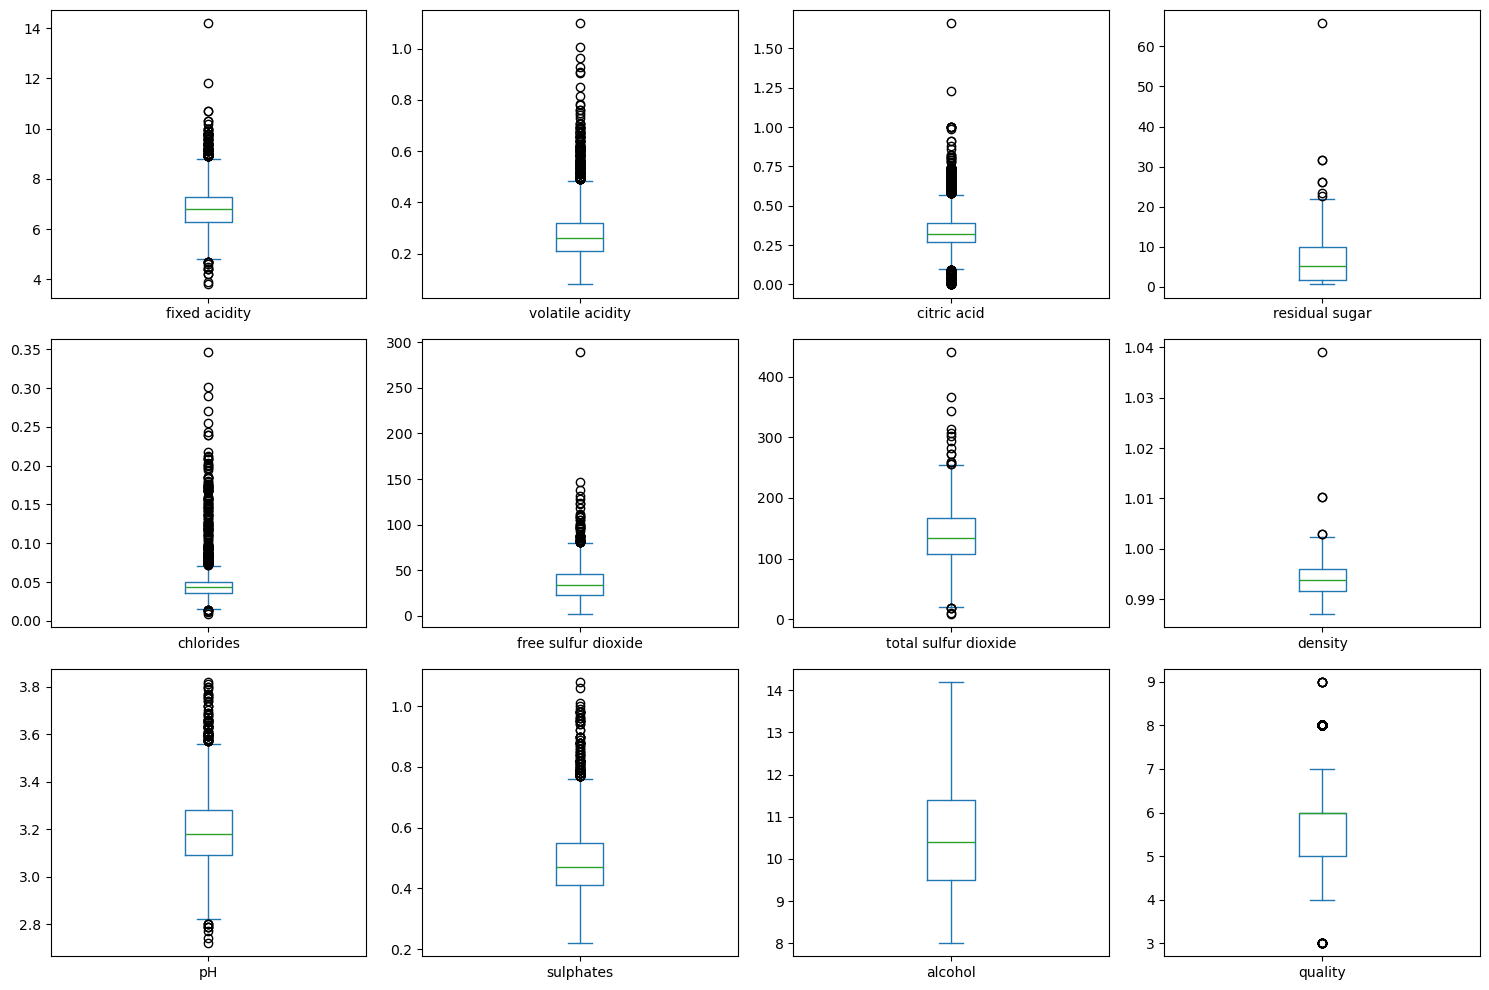

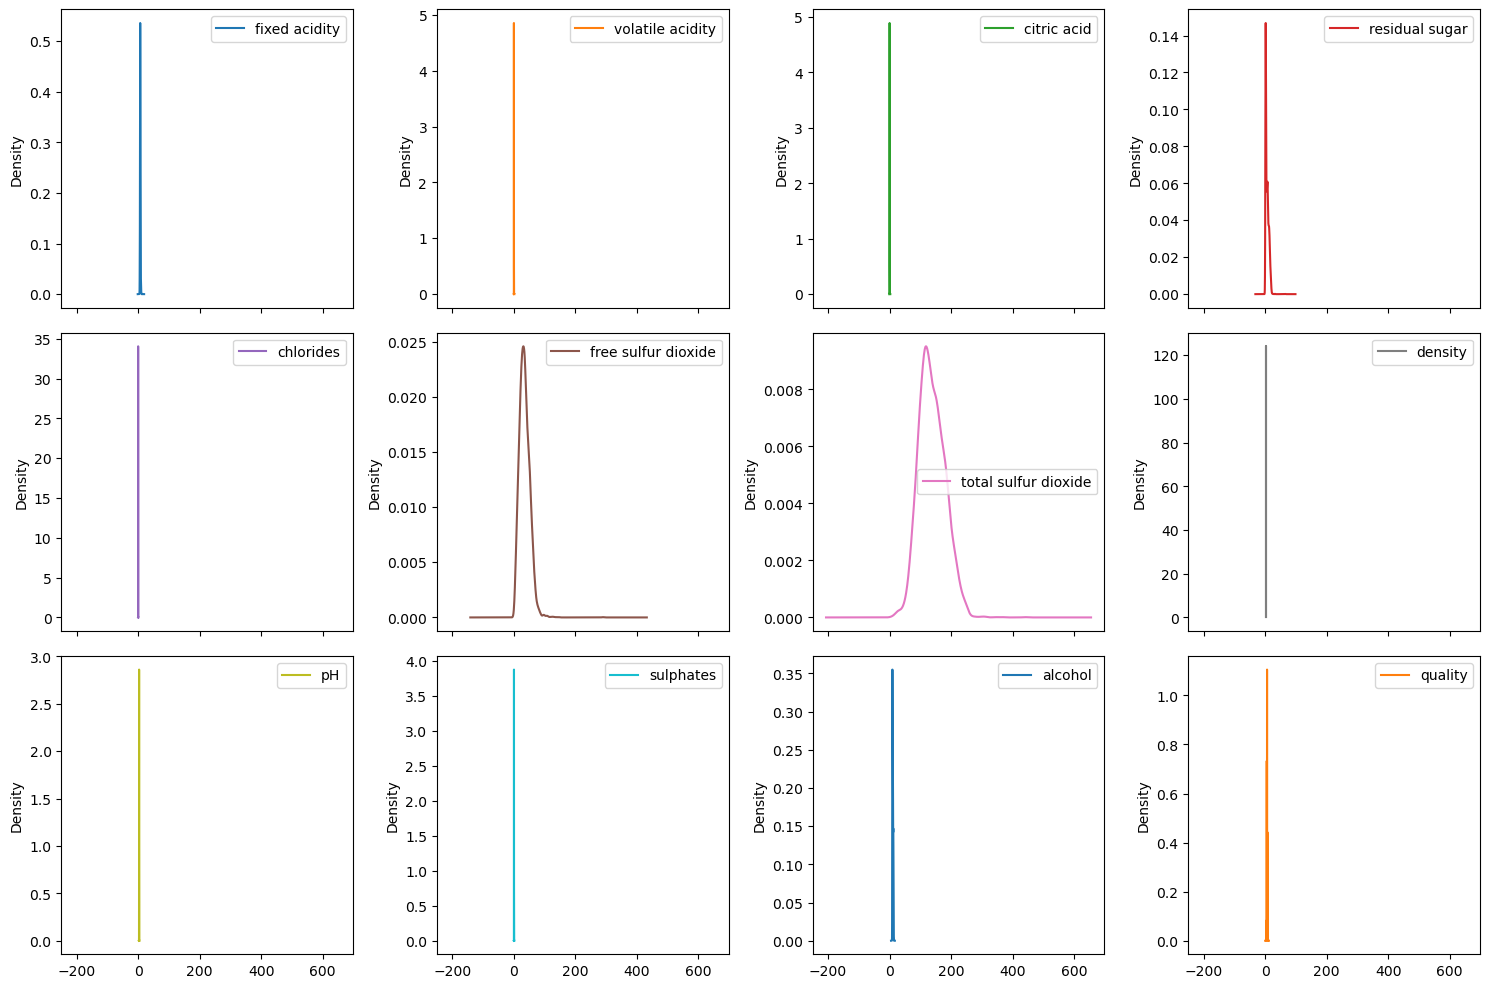

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

df = pd.read_csv("./data/winequality-white.csv", sep=';')

os.makedirs("plots", exist_ok=True)

df.hist(figsize=(15, 10))
plt.tight_layout()
plt.savefig("plots/histograms.png")  # save for upload
plt.show()

plt.figure()
df['quality'].value_counts().sort_index().plot(kind='bar')
plt.xlabel("Quality")
plt.ylabel("Count")
plt.title("Distribution of Wine Quality")
plt.tight_layout()
plt.savefig("plots/quality_distribution.png")
plt.show()

df.plot(kind='box', subplots=True, layout=(3,4), figsize=(15,10))
plt.tight_layout()
plt.savefig("plots/boxplots.png")
plt.show()

df.plot(kind='density', subplots=True, layout=(3,4), figsize=(15,10))
plt.tight_layout()
plt.savefig("plots/density.png")
plt.show()

In [ ]:
import pandas as pd

df = pd.read_csv("./data/winequality-white.csv", sep=';')

df_binary = df.copy()
df_binary['label'] = (df_binary['quality'] >= 7).astype(int)

df_binary = df_binary.drop(columns=['quality'])

cols = [col for col in df_binary.columns if col != 'label'] + ['label']
df_binary = df_binary[cols]

df_binary.to_csv("wine_binary.csv", index=False)

df_multi = df[(df['quality'] >= 4) & (df['quality'] <= 8)].copy()

df_multi['label'] = df_multi['quality']

df_multi = df_multi.drop(columns=['quality'])

cols = [col for col in df_multi.columns if col != 'label'] + ['label']
df_multi = df_multi[cols]

df_multi.to_csv("wine_multiclass.csv", index=False)

print("Binary dataset shape:", df_binary.shape)
print("Multi-class dataset shape:", df_multi.shape)

print("\nBinary label distribution:")
print(df_binary['label'].value_counts())

print("\nMulti-class label distribution:")
print(df_multi['label'].value_counts())

Binary dataset shape: (4898, 12)
Multi-class dataset shape: (4873, 12)

Binary label distribution:
label
0    3838
1    1060
Name: count, dtype: int64

Multi-class label distribution:
label
6    2198
5    1457
7     880
8     175
4     163
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

df = pd.read_csv("./data/wine_binary.csv")

X = df.drop(columns=['label'])
y = df['label']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.1, random_state=42
)

train_df = X_train.copy()
train_df['label'] = y_train

val_df = X_val.copy()
val_df['label'] = y_val

train_df.to_csv("train_binary.csv", index=False)
val_df.to_csv("val_binary.csv", index=False)

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)

Train shape: (4408, 12)
Validation shape: (490, 12)


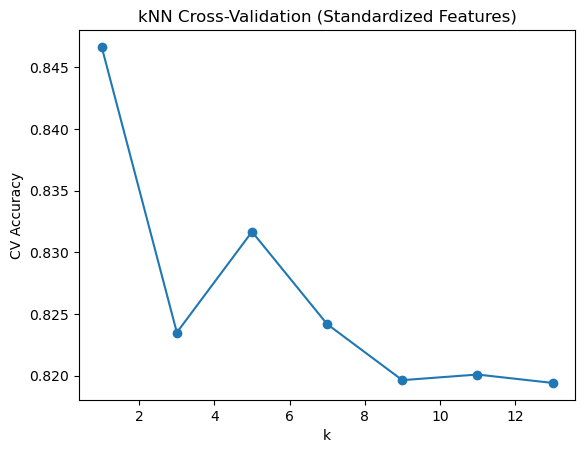

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

k_values = [1, 3, 5, 7, 9, 11, 13]
cv_scores = []

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for k in k_values:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])
    
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="accuracy")
    cv_scores.append(scores.mean())

plt.plot(k_values, cv_scores, marker='o')
plt.xlabel("k")
plt.ylabel("CV Accuracy")
plt.title("kNN Cross-Validation (Standardized Features)")
plt.savefig("knn_cv_scaled.png")
plt.show()

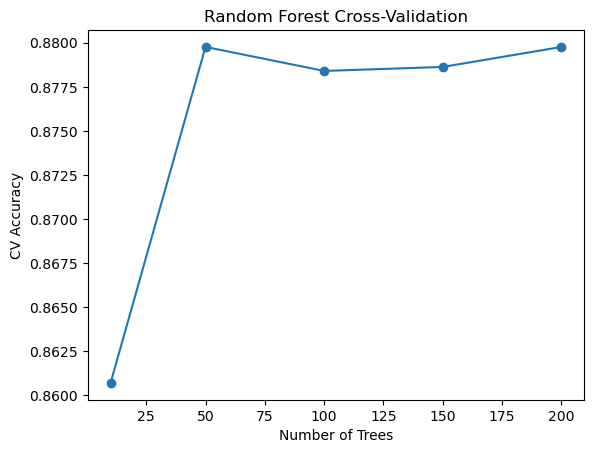

In [ ]:
from sklearn.ensemble import RandomForestClassifier

n_values = [10, 50, 100, 150, 200]
rf_scores = []

for n in n_values:
    model = RandomForestClassifier(n_estimators=n, random_state=42)
    scores = cross_val_score(model, X_train, y_train, cv=5)
    rf_scores.append(scores.mean())

plt.plot(n_values, rf_scores, marker='o')
plt.xlabel("Number of Trees")
plt.ylabel("CV Accuracy")
plt.title("Random Forest Cross-Validation")
plt.savefig("rf_cv.png")
plt.show()

In [ ]:
import time
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

knn_model = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=5))
])

start = time.time()
knn_model.fit(X_train, y_train)
knn_train_time = time.time() - start

y_train_pred_knn = knn_model.predict(X_train)
knn_train_acc = accuracy_score(y_train, y_train_pred_knn)

start = time.time()
y_val_pred_knn = knn_model.predict(X_val)
knn_test_time = time.time() - start

knn_val_acc = accuracy_score(y_val, y_val_pred_knn)

rf_model = RandomForestClassifier(n_estimators=50, random_state=42)

start = time.time()
rf_model.fit(X_train, y_train)
rf_train_time = time.time() - start

y_train_pred_rf = rf_model.predict(X_train)
rf_train_acc = accuracy_score(y_train, y_train_pred_rf)

start = time.time()
y_val_pred_rf = rf_model.predict(X_val)
rf_test_time = time.time() - start

rf_val_acc = accuracy_score(y_val, y_val_pred_rf)

print("kNN training accuracy:", knn_train_acc)
print("kNN training time:", knn_train_time)
print("kNN validation accuracy:", knn_val_acc)
print("kNN testing time:", knn_test_time)

print()

print("Random Forest training accuracy:", rf_train_acc)
print("Random Forest training time:", rf_train_time)
print("Random Forest validation accuracy:", rf_val_acc)
print("Random Forest testing time:", rf_test_time)

kNN training accuracy: 0.8833938294010889
kNN training time: 0.006142139434814453
kNN validation accuracy: 0.8489795918367347
kNN testing time: 0.013695240020751953

Random Forest training accuracy: 1.0
Random Forest training time: 0.20607852935791016
Random Forest validation accuracy: 0.9020408163265307
Random Forest testing time: 0.004015684127807617


In [ ]:
df = pd.read_csv("./data/wine_multiclass.csv")

# split features and label
X = df.drop(columns=["label"])
y = df["label"]

# 90% train, 10% validation
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.1,
    random_state=42,
    stratify=y
)

train_df = X_train.copy()
train_df["label"] = y_train
train_df.to_csv("train_multiclass.csv", index=False)

val_df = X_val.copy()
val_df["label"] = y_val
val_df.to_csv("val_multiclass.csv", index=False)

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("\nTraining label distribution:")
print(y_train.value_counts().sort_index())
print("\nValidation label distribution:")
print(y_val.value_counts().sort_index())

Train shape: (4385, 12)
Validation shape: (488, 12)

Training label distribution:
label
4     147
5    1311
6    1978
7     792
8     157
Name: count, dtype: int64

Validation label distribution:
label
4     16
5    146
6    220
7     88
8     18
Name: count, dtype: int64


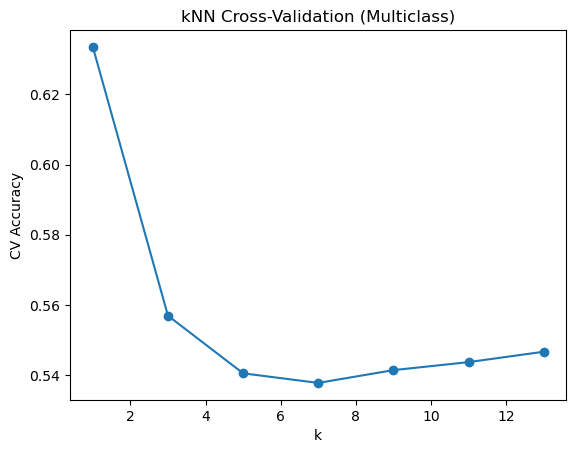

[(1, np.float64(0.6335233751425313)), (3, np.float64(0.5568985176738883)), (5, np.float64(0.5404789053591791)), (7, np.float64(0.5377423033067276)), (9, np.float64(0.5413911060433295)), (11, np.float64(0.5436716077537058)), (13, np.float64(0.546636259977195))]


In [ ]:
k_values = [1, 3, 5, 7, 9, 11, 13]
cv_scores = []

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for k in k_values:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])
    
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="accuracy")
    cv_scores.append(scores.mean())

plt.plot(k_values, cv_scores, marker='o')
plt.xlabel("k")
plt.ylabel("CV Accuracy")
plt.title("kNN Cross-Validation (Multiclass)")
plt.savefig("knn_cv_multiclass.png")
plt.show()

print(list(zip(k_values, cv_scores)))

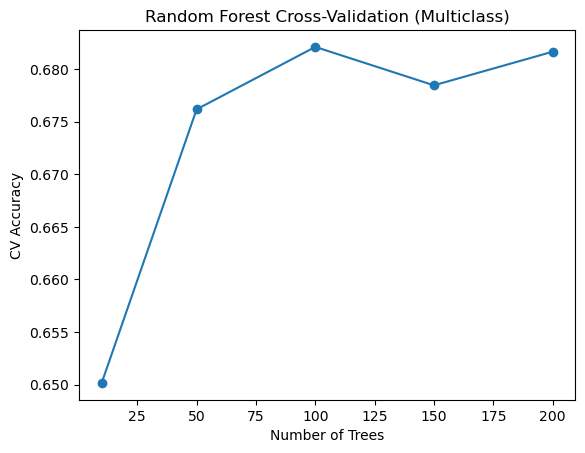

[(10, np.float64(0.6501710376282783)), (50, np.float64(0.6761687571265679)), (100, np.float64(0.6820980615735461)), (150, np.float64(0.6784492588369442)), (200, np.float64(0.6816419612314709))]


In [ ]:
n_values = [10, 50, 100, 150, 200]
rf_scores = []

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for n in n_values:
    model = RandomForestClassifier(n_estimators=n, random_state=42)
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="accuracy")
    rf_scores.append(scores.mean())

plt.plot(n_values, rf_scores, marker='o')
plt.xlabel("Number of Trees")
plt.ylabel("CV Accuracy")
plt.title("Random Forest Cross-Validation (Multiclass)")
plt.savefig("rf_cv_multiclass.png")
plt.show()

print(list(zip(n_values, rf_scores)))

In [ ]:
knn_model = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=3))
])

start = time.time()
knn_model.fit(X_train, y_train)
knn_train_time = time.time() - start

y_train_pred_knn = knn_model.predict(X_train)
knn_train_acc = accuracy_score(y_train, y_train_pred_knn)

start = time.time()
y_val_pred_knn = knn_model.predict(X_val)
knn_test_time = time.time() - start

knn_val_acc = accuracy_score(y_val, y_val_pred_knn)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

start = time.time()
rf_model.fit(X_train, y_train)
rf_train_time = time.time() - start
y_train_pred_rf = rf_model.predict(X_train)
rf_train_acc = accuracy_score(y_train, y_train_pred_rf)

start = time.time()
y_val_pred_rf = rf_model.predict(X_val)
rf_test_time = time.time() - start

rf_val_acc = accuracy_score(y_val, y_val_pred_rf)

print("kNN training accuracy:", knn_train_acc)
print("kNN training time:", knn_train_time)
print("kNN validation accuracy:", knn_val_acc)
print("kNN testing time:", knn_test_time)

print()

print("Random Forest training accuracy:", rf_train_acc)
print("Random Forest training time:", rf_train_time)
print("Random Forest validation accuracy:", rf_val_acc)
print("Random Forest testing time:", rf_test_time)

kNN training accuracy: 0.7956670467502851
kNN training time: 0.005669593811035156
kNN validation accuracy: 0.5471311475409836
kNN testing time: 0.013495922088623047

Random Forest training accuracy: 1.0
Random Forest training time: 0.5515146255493164
Random Forest validation accuracy: 0.7172131147540983
Random Forest testing time: 0.009964227676391602


In [ ]:
from sklearn.decomposition import PCA

df = pd.read_csv("./data/wine_binary.csv")

X = df.drop(columns=["label"])
y = df["label"]

# 1. split first
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X, y,
    test_size=0.1,
    random_state=42,
    stratify=y
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_val_scaled = scaler.transform(X_val_raw)

pca = PCA(n_components=5)
X_train = pca.fit_transform(X_train_scaled)
X_val = pca.transform(X_val_scaled)

train_df = pd.DataFrame(X_train)
train_df["label"] = y_train.values
train_df.to_csv("train_binary_pca.csv", index=False)

val_df = pd.DataFrame(X_val)
val_df["label"] = y_val.values
val_df.to_csv("val_binary_pca.csv", index=False)

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)

Train shape: (4408, 6)
Validation shape: (490, 6)


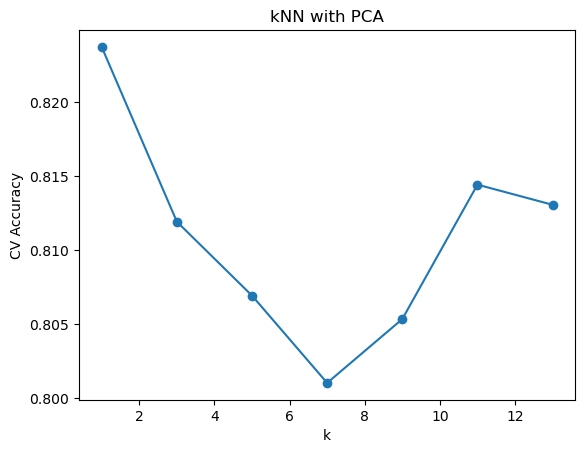

In [ ]:
k_values = [1, 3, 5, 7, 9, 11, 13]
cv_scores = []

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="accuracy")
    cv_scores.append(scores.mean())

plt.plot(k_values, cv_scores, marker='o')
plt.xlabel("k")
plt.ylabel("CV Accuracy")
plt.title("kNN with PCA")
plt.savefig("knn_pca.png")
plt.show()

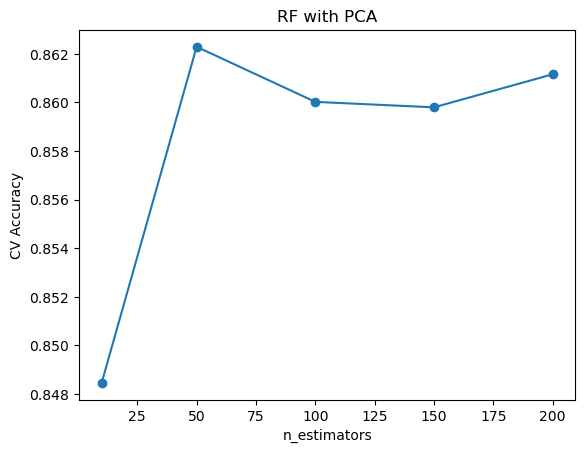

In [ ]:
n_values = [10,50,100,150,200]
rf_scores = []

for n in n_values:
    model = RandomForestClassifier(n_estimators=n, random_state=42)
    scores = cross_val_score(model, X_train, y_train, cv=5)
    rf_scores.append(scores.mean())

plt.plot(n_values, rf_scores, marker='o')
plt.title("RF with PCA")
plt.xlabel("n_estimators")
plt.ylabel("CV Accuracy")
plt.savefig("rf_pca.png")
plt.show()

In [ ]:
knn_model = KNeighborsClassifier(n_neighbors=11)

start = time.time()
knn_model.fit(X_train, y_train)
knn_train_time = time.time() - start

y_train_pred_knn = knn_model.predict(X_train)
knn_train_acc = accuracy_score(y_train, y_train_pred_knn)

start = time.time()
y_val_pred_knn = knn_model.predict(X_val)
knn_test_time = time.time() - start

knn_val_acc = accuracy_score(y_val, y_val_pred_knn)

rf_model = RandomForestClassifier(n_estimators=50, random_state=42)

start = time.time()
rf_model.fit(X_train, y_train)
rf_train_time = time.time() - start

y_train_pred_rf = rf_model.predict(X_train)
rf_train_acc = accuracy_score(y_train, y_train_pred_rf)

start = time.time()
y_val_pred_rf = rf_model.predict(X_val)
rf_test_time = time.time() - start

rf_val_acc = accuracy_score(y_val, y_val_pred_rf)

print("kNN training accuracy:", knn_train_acc)
print("kNN training time:", knn_train_time)
print("kNN validation accuracy:", knn_val_acc)
print("kNN testing time:", knn_test_time)

print()

print("Random Forest training accuracy:", rf_train_acc)
print("Random Forest training time:", rf_train_time)
print("Random Forest validation accuracy:", rf_val_acc)
print("Random Forest testing time:", rf_test_time)

kNN training accuracy: 0.8446007259528131
kNN training time: 0.0030994415283203125
kNN validation accuracy: 0.8306122448979592
kNN testing time: 0.004258871078491211

Random Forest training accuracy: 0.9995462794918331
Random Forest training time: 0.24571585655212402
Random Forest validation accuracy: 0.8775510204081632
Random Forest testing time: 0.0038924217224121094


In [ ]:
df = pd.read_csv("./data/wine_multiclass.csv")

X = df.drop(columns=["label"])
y = df["label"]

X = df.drop(columns=["label"])
y = df["label"]

X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X, y,
    test_size=0.1,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_val_scaled = scaler.transform(X_val_raw)

pca = PCA(n_components=5)
X_train = pca.fit_transform(X_train_scaled)
X_val = pca.transform(X_val_scaled)

train_df = pd.DataFrame(X_train)
train_df["label"] = y_train.values
train_df.to_csv("train_multiclass_pca.csv", index=False)

val_df = pd.DataFrame(X_val)
val_df["label"] = y_val.values
val_df.to_csv("val_multiclass_pca.csv", index=False)

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)

Train shape: (4385, 6)
Validation shape: (488, 6)


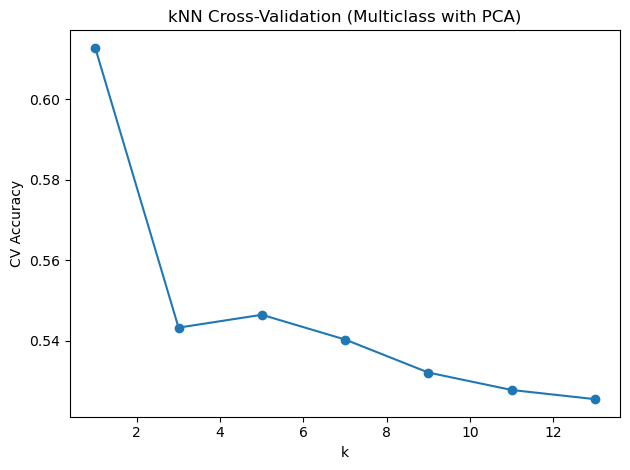

[(1, np.float64(0.6127708095781073)), (3, np.float64(0.5432155074116306)), (5, np.float64(0.5464082098061575)), (7, np.float64(0.5402508551881413)), (9, np.float64(0.5320410490307868)), (11, np.float64(0.5277080957810718)), (13, np.float64(0.5254275940706956))]


In [ ]:
k_values = [1, 3, 5, 7, 9, 11, 13]
cv_scores = []

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="accuracy")
    cv_scores.append(scores.mean())

plt.figure()
plt.plot(k_values, cv_scores, marker='o')
plt.xlabel("k")
plt.ylabel("CV Accuracy")
plt.title("kNN Cross-Validation (Multiclass with PCA)")
plt.tight_layout()
plt.savefig("knn_cv_multiclass_pca.png")
plt.show()

print(list(zip(k_values, cv_scores)))

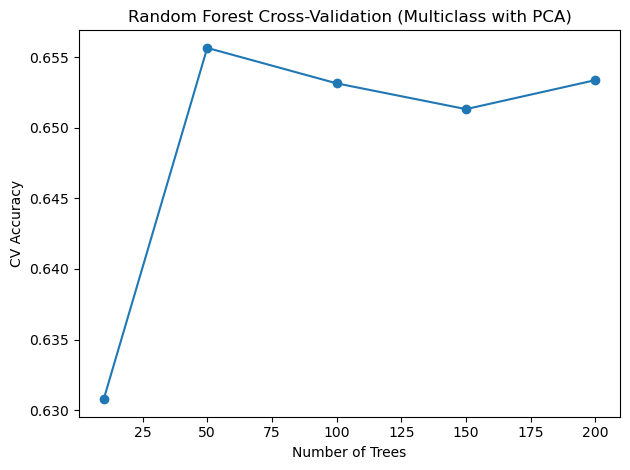

[(10, np.float64(0.6307867730900798)), (50, np.float64(0.6556442417331813)), (100, np.float64(0.6531356898517674)), (150, np.float64(0.6513112884834664)), (200, np.float64(0.6533637400228051))]


In [ ]:
n_values = [10, 50, 100, 150, 200]
rf_scores = []

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for n in n_values:
    model = RandomForestClassifier(n_estimators=n, random_state=42)
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="accuracy")
    rf_scores.append(scores.mean())

plt.figure()
plt.plot(n_values, rf_scores, marker='o')
plt.xlabel("Number of Trees")
plt.ylabel("CV Accuracy")
plt.title("Random Forest Cross-Validation (Multiclass with PCA)")
plt.tight_layout()
plt.savefig("rf_cv_multiclass_pca.png")
plt.show()

print(list(zip(n_values, rf_scores)))

In [ ]:
knn_model = KNeighborsClassifier(n_neighbors=5)

start = time.time()
knn_model.fit(X_train, y_train)
knn_train_time = time.time() - start

y_train_pred_knn = knn_model.predict(X_train)
knn_train_acc = accuracy_score(y_train, y_train_pred_knn)

start = time.time()
y_val_pred_knn = knn_model.predict(X_val)
knn_test_time = time.time() - start

knn_val_acc = accuracy_score(y_val, y_val_pred_knn)

rf_model = RandomForestClassifier(n_estimators=50, random_state=42)

start = time.time()
rf_model.fit(X_train, y_train)
rf_train_time = time.time() - start

y_train_pred_rf = rf_model.predict(X_train)
rf_train_acc = accuracy_score(y_train, y_train_pred_rf)

start = time.time()
y_val_pred_rf = rf_model.predict(X_val)
rf_test_time = time.time() - start

rf_val_acc = accuracy_score(y_val, y_val_pred_rf)

print("kNN training accuracy:", knn_train_acc)
print("kNN training time:", knn_train_time)
print("kNN validation accuracy:", knn_val_acc)
print("kNN testing time:", knn_test_time)

print()

print("Random Forest training accuracy:", rf_train_acc)
print("Random Forest training time:", rf_train_time)
print("Random Forest validation accuracy:", rf_val_acc)
print("Random Forest testing time:", rf_test_time)

kNN training accuracy: 0.7076396807297606
kNN training time: 0.003388643264770508
kNN validation accuracy: 0.569672131147541
kNN testing time: 0.0033648014068603516

Random Forest training accuracy: 1.0
Random Forest training time: 0.306581974029541
Random Forest validation accuracy: 0.6823770491803278
Random Forest testing time: 0.004166603088378906
